In [1]:
Threads.nthreads()

4

In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2


  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


# Definició model

In [3]:
moving_source_model = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :isSource => Bool, 
        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64,
        :v_source => Float64

        # :xs => Float64,
        # :ys => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :DSource => Float64,
        :delta => Float64,
    ),

    medium = Dict(
        :mm => Float64
    ),

    agentODE = quote

        xmin, xmax = simBox[1,1]*0.9, simBox[1,2]*0.9
        ymin, ymax = simBox[2,1]*0.9, simBox[2,2]*0.9
        # X direction
        if x < xmin
            x += (xmax - xmin)
        elseif x > xmax
            x -= (xmax - xmin)
        end

        # Y direction
        if y < ymin
            y += (ymax - ymin)
        elseif y > ymax
            y -= (ymax - ymin)
        end

        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = active * vx  #Change position acording to constant speed afected by forces
        dt(y) = active * vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote

        if isSource
            active = false
            vx = v_source * cos(theta)
            vy = v_source * sin(theta)
            x += vx * dt
            y += vy * dt
            theta += sqrt(2 * DSource * dt) * randn()
            mm += S
        else

            v_run = v
            v_tumble = 0.25 

            speed = active ? v_run : v_tumble

            Dr_tumble = 6.2      
            Dr_total = active ? Dr_run : Dr_tumble

            if active 
                λ = ωFrec*exp(-G)
                P = 1 - exp(-λ * dt)
                
            else
                λ = ωFrec*exp(G)
                P = 1 - exp(-λ * dt)  
                
            end


            if active 
                λrt = ωFrec*exp(-G) 

                P_rt = 1 - exp(-λrt * dt)
                P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                    active = false
                    vx = speed
                    vy = speed
                    theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
                else     #Si rate baixa 
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
                end

            else
                λtr = ωFrec*exp(G) 
                P_tr = 1 - exp(-λtr * dt)
                P = rand()

                if P < P_tr
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                else
                    active = false
                    vx = speed
                    vy = speed
                    theta += sqrt(2 * Dr_total * dt) * randn()
                end
            end
        end

        # if x < simBox[1,1]*0.8
        #     x = simBox[1,1]*0.8
        # elseif x > simBox[1,2]*0.8
        #     x = simBox[1,2]*0.8
        # end
        # if y < simBox[2,1]*0.8
        #     y = simBox[2,1]*0.8
        # elseif y > simBox[2,2]*0.8
        #     y = simBox[2,2]*0.8
        # end



        #Un altre manera que m'ha donat pero no entenc.

        # Lx = xmax - xmin
        # Ly = ymax - ymin

        # x = xmin + mod(x - xmin, Lx)
        # y = ymin + mod(y - ymin, Ly)

    end,

    mediumODE = quote
        if @mediumInside()
            dt(mm) = DMedium *(@∂2(1, mm)+ @∂2(2, mm)) - delta*mm 
        elseif @mediumBorder(1,-1)
            mm = 0
        elseif @mediumBorder(1,1)
            mm = 0
        elseif @mediumBorder(2,1)
            mm = 0
        elseif @mediumBorder(2,-1)
            mm = 0
        end
    end,

    neighborsAlg = CBMNeighbors.CellLinked(cellEdge = 4)
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	xₘ (Float64 medium)
	yₘ (Float64 medium)
	F (Float64 agent)
	active (Bool agent)
	v_source (Float64 agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	isSource (Bool agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	DSource (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)
	mm (Float64 medium)


UPDATE RULES
med

# Carrega community

In [4]:
com = Community(
    moving_source_model,
    N=21,
    dt=0.01,
    # simBox = [-20.0 20.0; -20.0 20.0],
    simBox = [-100.0 100.0; -100.0 100.0],
    # simBox = [-50.0 50.0; -50.0 50.0],
    # NMedium = [100, 100]
    NMedium = [200, 200]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v =  0.33   #Velocitat neutrophil (20 microm/min) 
# com.v = 20.0    #(microm/s)
com.v = 10.0
# com.v = 5.0
# com.v = 2.5
# com.v = 1

# com.v_source = 0.1
# com.v_source = 0.15
# com.v_source = 0.25
# com.v_source = 0.5
com.v_source = 10
# com.v_source = 1.5
# com.v_source = 2
# com.v_source = 5
# com.v_source = 10


# com.DMedium = 100
com.DMedium = 10
# com.DMedium = 1
# com.DMedium = 0.1
# com.DMedium = 0.01
# com.DMedium = 0.001
# com.DMedium = 0.0001

com.DSource = 0.063
com.delta = 0.01
# com.delta = 0.1
# com.delta = 1.0
# com.delta = 10

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

# com.τm = 0.1
# com.τm = 0.5
com.τm = 3.162
# com.τm = 1.0
# com.τm = 2.0
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

# com.x = rand(Uniform(com.simBox[1,:]...),com.N)
# com.y = rand(Uniform(com.simBox[2,:]...),com.N)
com.x = 0.0
com.y = 0.0
com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K

src = 1

com.isSource .= false
com.isSource[src] = true

com.active .= true 
com.active[src] = false   

com.S .= 0.0
# com.xs .= 0.0
# com.ys .= 0.0
# com.xs[src] = com.x[src]
# com.ys[src] = com.y[src]

# com.S[src] = 0.1
com.S[src] = 2.6
# com.S[src] = 10
# com.S[src] = 100
# com.S[src] = 1000

2.6

# Evoluciona i guarda

In [ ]:
outfile = "r_omega_1.jld2"
steps = 10000

loadToPlatform!(com, preallocateAgents=21)
com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Metadata (written once)
    # -------------------------
    meta = JLD2.Group(file, "meta")
    meta["N"] = com.N
    meta["NMedium"] = com.NMedium
    meta["steps"] = steps

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["theta"] = copy(com.theta)

        g["isSource"] = copy(com.isSource)

        g["v_source"] = copy(com.v_source)
        g["DMedium"] = copy(com.DMedium)
        g["v"] = copy(com.v)
        g["delta"] = copy(com.delta)
        g["tm"] = copy(com.τm)


        # Medium grid (saved once per step)
        g["mm_grid"] = copy(com.mm)

        if step %10 == 0
            println("step:" ,step, " max(mm) = ", maximum(com.mm), "max(|x|) = ", maximum(abs.(com.x)),"max(|y|) = ", maximum(abs.(com.y)))
        end
    end
end


step:10 max(mm) = 6.849261847942761max(|x|) = 0.5952580752955123max(|y|) = 0.8603630542958366
step:20 max(mm) = 8.082283315660002max(|x|) = 1.5510827901381812max(|y|) = 1.8218454072904413
step:30 max(mm) = 8.619680586125556max(|x|) = 2.518066542974102max(|y|) = 2.7492409959582367
step:40 max(mm) = 8.273989590542959max(|x|) = 3.5157192468136573max(|y|) = 3.6732213469298327
step:50 max(mm) = 8.638350096442137max(|x|) = 4.50711523151212max(|y|) = 4.56298339208696
step:60 max(mm) = 7.269879998860343max(|x|) = 5.490965171108407max(|y|) = 5.494380605062664
step:70 max(mm) = 7.512358944525885max(|x|) = 6.452237273773071max(|y|) = 6.425398764786785
step:80 max(mm) = 7.319294341564293max(|x|) = 7.429610166863743max(|y|) = 7.35780287850093
step:90 max(mm) = 6.843071978710494max(|x|) = 8.424771631607799max(|y|) = 8.357039772628122
step:100 max(mm) = 8.215722833062289max(|x|) = 9.42213233610319max(|y|) = 9.35486615984105
step:110 max(mm) = 8.253123765153036max(|x|) = 10.421614677990897max(|y|) = 1

# Plots

In [5]:
steps = 10000

10000

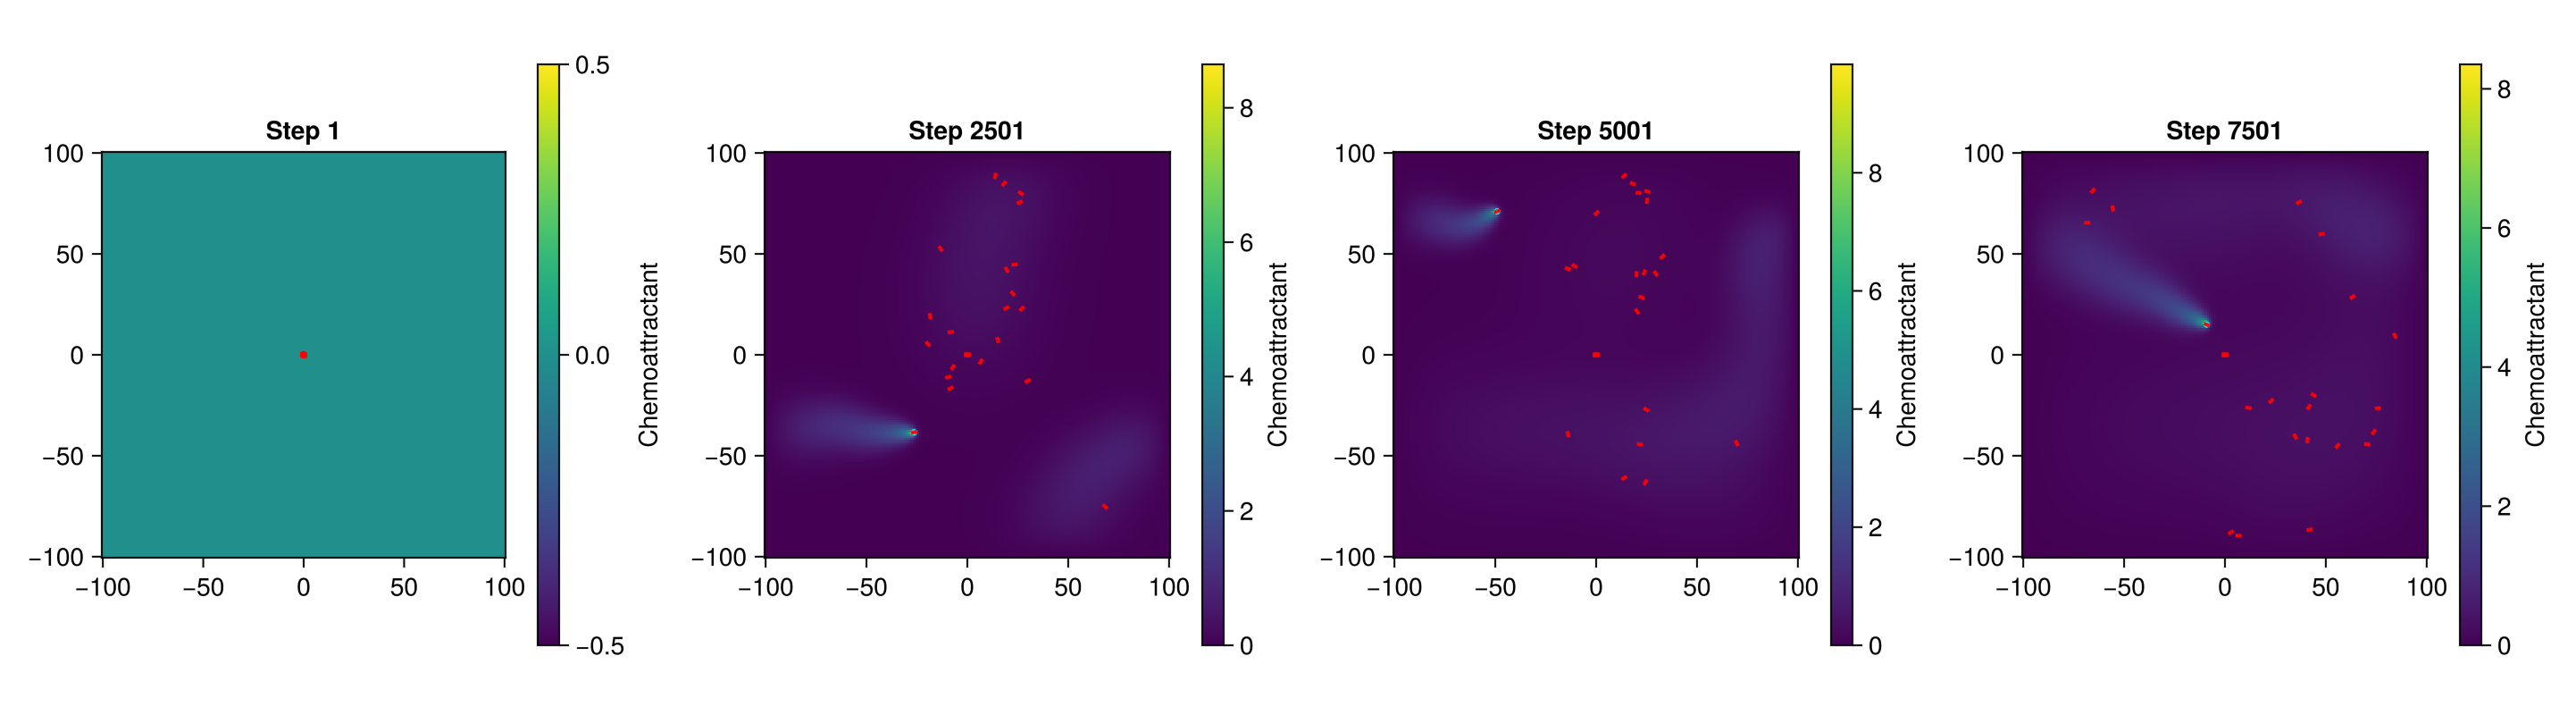

GLMakie.Screen(...)

In [6]:
fig4 = Figure(size=(1800,400))

model_steps = 1:steps
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/4):end]

jldopen("r_omega_1.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        x = Vector{Float64}(undef, 21)
        y = Vector{Float64}(undef, 21)

        ax = Axis(fig4[1, 2*j-1], aspect=1, title="Step $step")

        g = file[@sprintf("step_%06d", step)]
    
        mm_grid = g["mm_grid"]
        mm = reshape(mm_grid, (200,200))

        hm = heatmap!(ax, 
                    range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                    range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                    mm_grid, 
                    colormap=:viridis
                    )

        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3
                
        scatter!(ax, x[1], y[1], color=:cyan, markersize=5, label="Source")
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
        end

        Colorbar(fig4[1, 2*j], hm, label="Chemoattractant")

    end
end

display(fig4)

In [5]:
data = Dict{Int, Any}()
steps = 10000
jldopen("r_omega_1.jld2", "r") do file
    for step in 1:steps
        key = file[@sprintf("step_%06d", step)]
        data[step] = Dict(
            "x" => copy(key["x"]),
            "y" => copy(key["y"]),
            "theta" => copy(key["theta"]),
            "mm_grid" => copy(key["mm_grid"])
        )
    end
end

# Setup plot
fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], aspect=1, title="Step 1", xlabel="x (μm)", ylabel="y (μm)")

# Initialize scatter and lines
scatter_plt = scatter!(ax, Float64[], Float64[], color=:red, markersize=5, label="Bacteria")
source_plt = scatter!(ax, [0.0], [0.0], color=:cyan, markersize=5, label="Source")

# Slider
slider = Slider(fig[2, 1:2], range=1:steps, startvalue=1, update_while_dragging = true)
Label(fig[2, 3], "Step: ", fontsize=14)

# Update function
function update_plot(step)
    empty!(ax)

    g = data[step]
    mm_grid = g["mm_grid"]
    mm = reshape(mm_grid, (200,200))

    hm = heatmap!(ax, 
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                mm_grid, 
                colormap=:viridis
                    )

    # Colorbar(fig[1, 2], hm, label="mm (μM)")

    
    x = g["x"]
    y = g["y"]
    theta = g["theta"]
    l = 3

    # Update scatter
    scatter_plt[1] = x
    scatter_plt[2] = y

    # Compute rod endpoints
    xs1 = x .+ l ./ 2 .* cos.(theta)
    ys1 = y .+ l ./ 2 .* sin.(theta)
    xs2 = x .- l ./ 2 .* cos.(theta)
    ys2 = y .- l ./ 2 .* sin.(theta)
    
    for i in 1:length(x)
        linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
        linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
    end

    # Update title
    ax.title = "Step $step"

    # Redraw
    autolimits!(ax)
end

# Connect slider to update
on(slider.value) do val
    update_plot(Int(val))
end

# Initialize
update_plot(1)

# Display
# display(fig)

GLMakie.activate!()
display(fig)

GLMakie.Screen(...)

In [6]:
save("Plots/source_nous_parametres.png", fig4)

## Mean distance to source

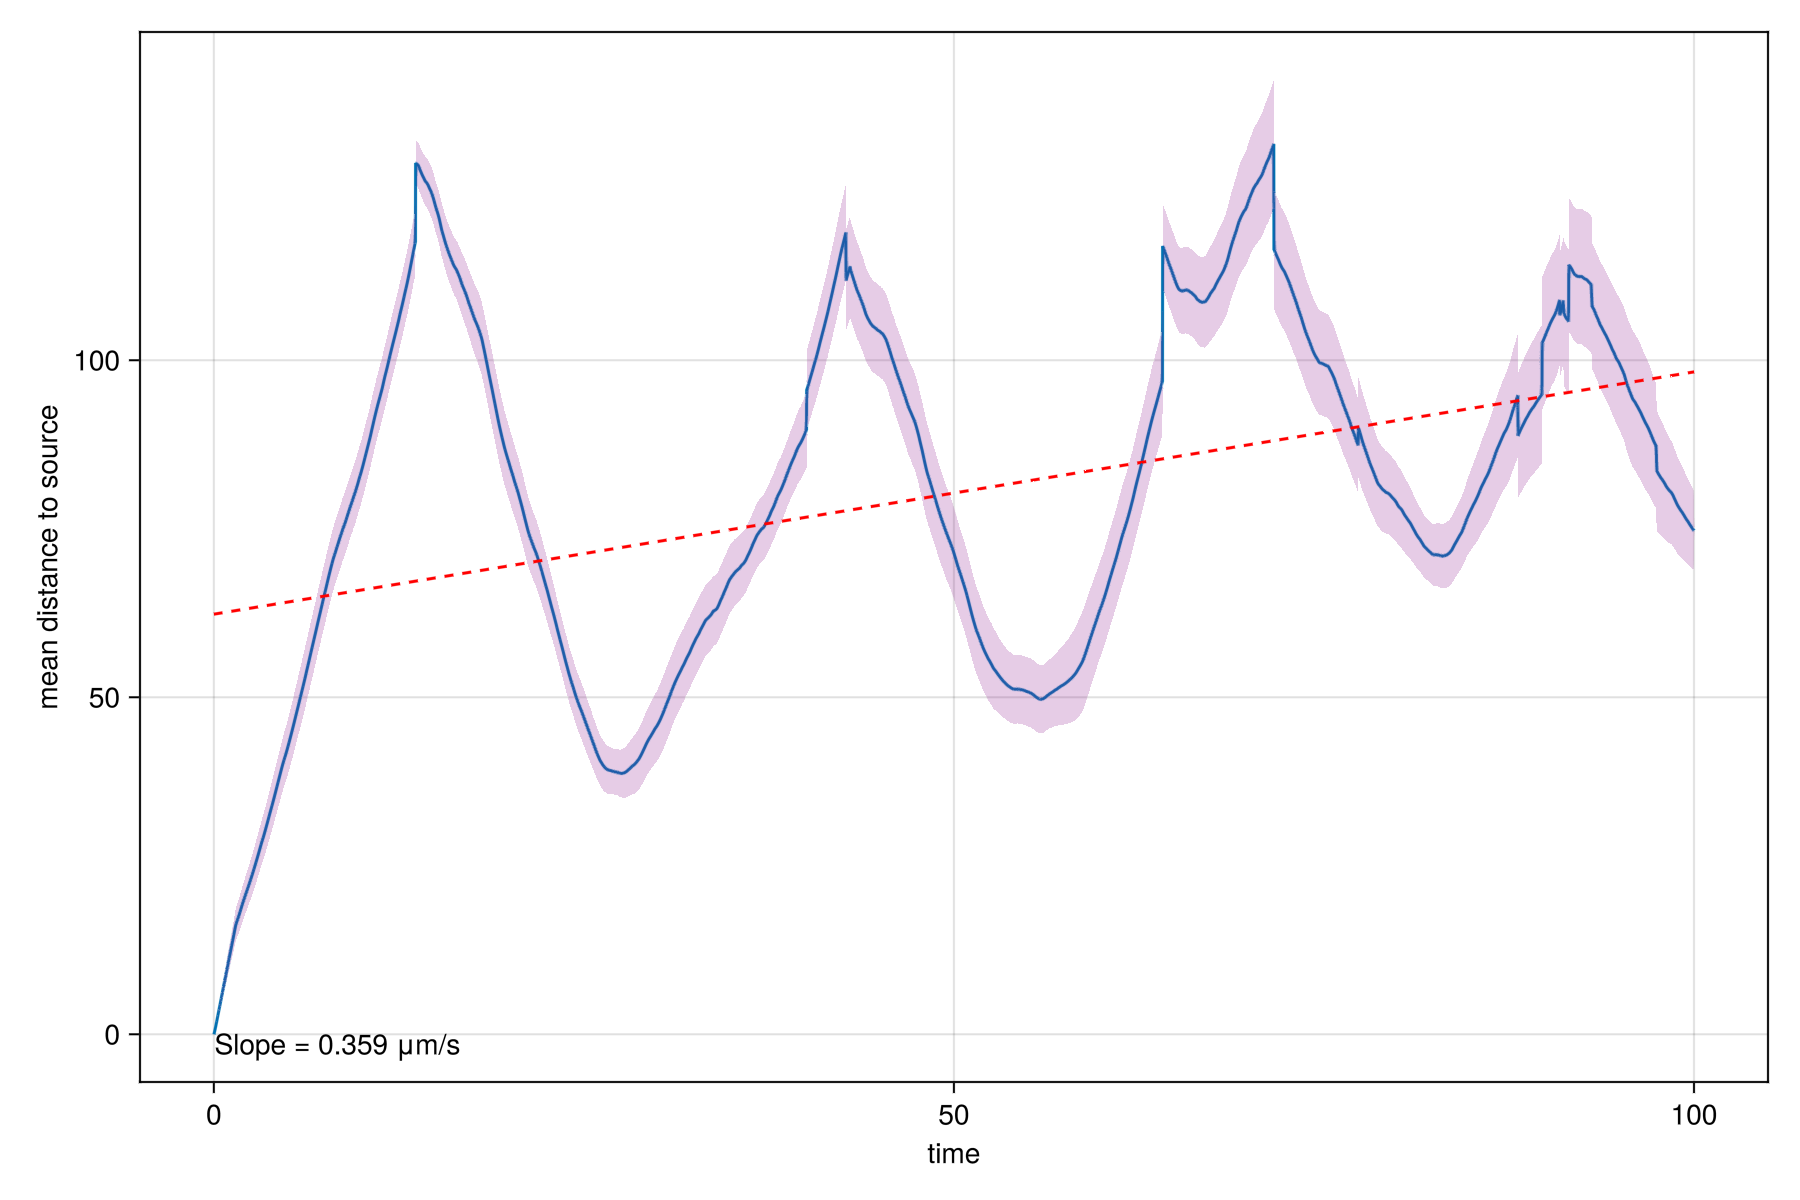

GLMakie.Screen(...)

In [6]:
fig = Figure(size=(900, 600))
ax1 = Axis(fig[1,1], xlabel="time", ylabel="mean distance to source")

mean_dist = Float64[] 
std_dist = Float64[]

jldopen("ratios_1.jld2", "r") do file 

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        src = 1

        xs = g["x"][1]
        ys = g["y"][1]

        # other_x = g["x"][2]
        other_x = g["x"][2:21]
        # other_y = g["y"][2]
        other_y = g["y"][2:21]

        dists = sqrt.((other_x .- xs).^2 .+ (other_y .- ys).^2)

        push!(mean_dist, mean(dists))
        push!(std_dist, std(dists))

    end

    time = (1:steps) * 0.01 
    slope = (steps * sum(time .* mean_dist) - sum(time) * sum(mean_dist)) / (steps * sum(time .^ 2) - sum(time)^2)
    intercept = mean(mean_dist) - slope * mean(time)

    std_dist_1 = std_dist ./ sqrt(20)

    lines!(ax1, (1:steps)*0.01, mean_dist)
    band!(ax1, (1:steps)*0.01, mean_dist .- std_dist_1, mean_dist .+ std_dist_1, color=(:purple, 0.2), label = "Standard deviation") 

    text!(ax1, 0.05, 0.95,text =  "Slope = $(round(slope, digits=3)) μm/s", 
          align=(:left, :top), 
          fontsize=14, 
          color=:black)

    # sideinfo = Label(fig4[2, 1:2], "Model parameters = Box size: $(com.simBox), v: [$(com.v[1])μm/s], tm: [$(com.τm)s]", justification = :left, color = :grey)

    lines!(ax1, time, slope .* time .+ intercept, color=:red, linestyle=:dash, label="Linear fit")
end
display(fig)

In [16]:
save("Plots/Moving_source_model/source_dist_v_source_1.png", fig)

# Ratios analysis


In [21]:
Dc = com.DMedium[1]

100.0

In [22]:
l = sqrt(com.DMedium[1]/com.delta[1])
τs = l^2 / com.v_source[1]
τv = l / com.v[1]
τc = l^2 / com.DMedium[1]

ratio_phi = com.τm[1] / τv
ratio_pi = com.τm[1] / τs
ratio_omega = com.τm[1] / τc

println(ratio_phi, ratio_omega, ratio_pi)

1.01.00.1


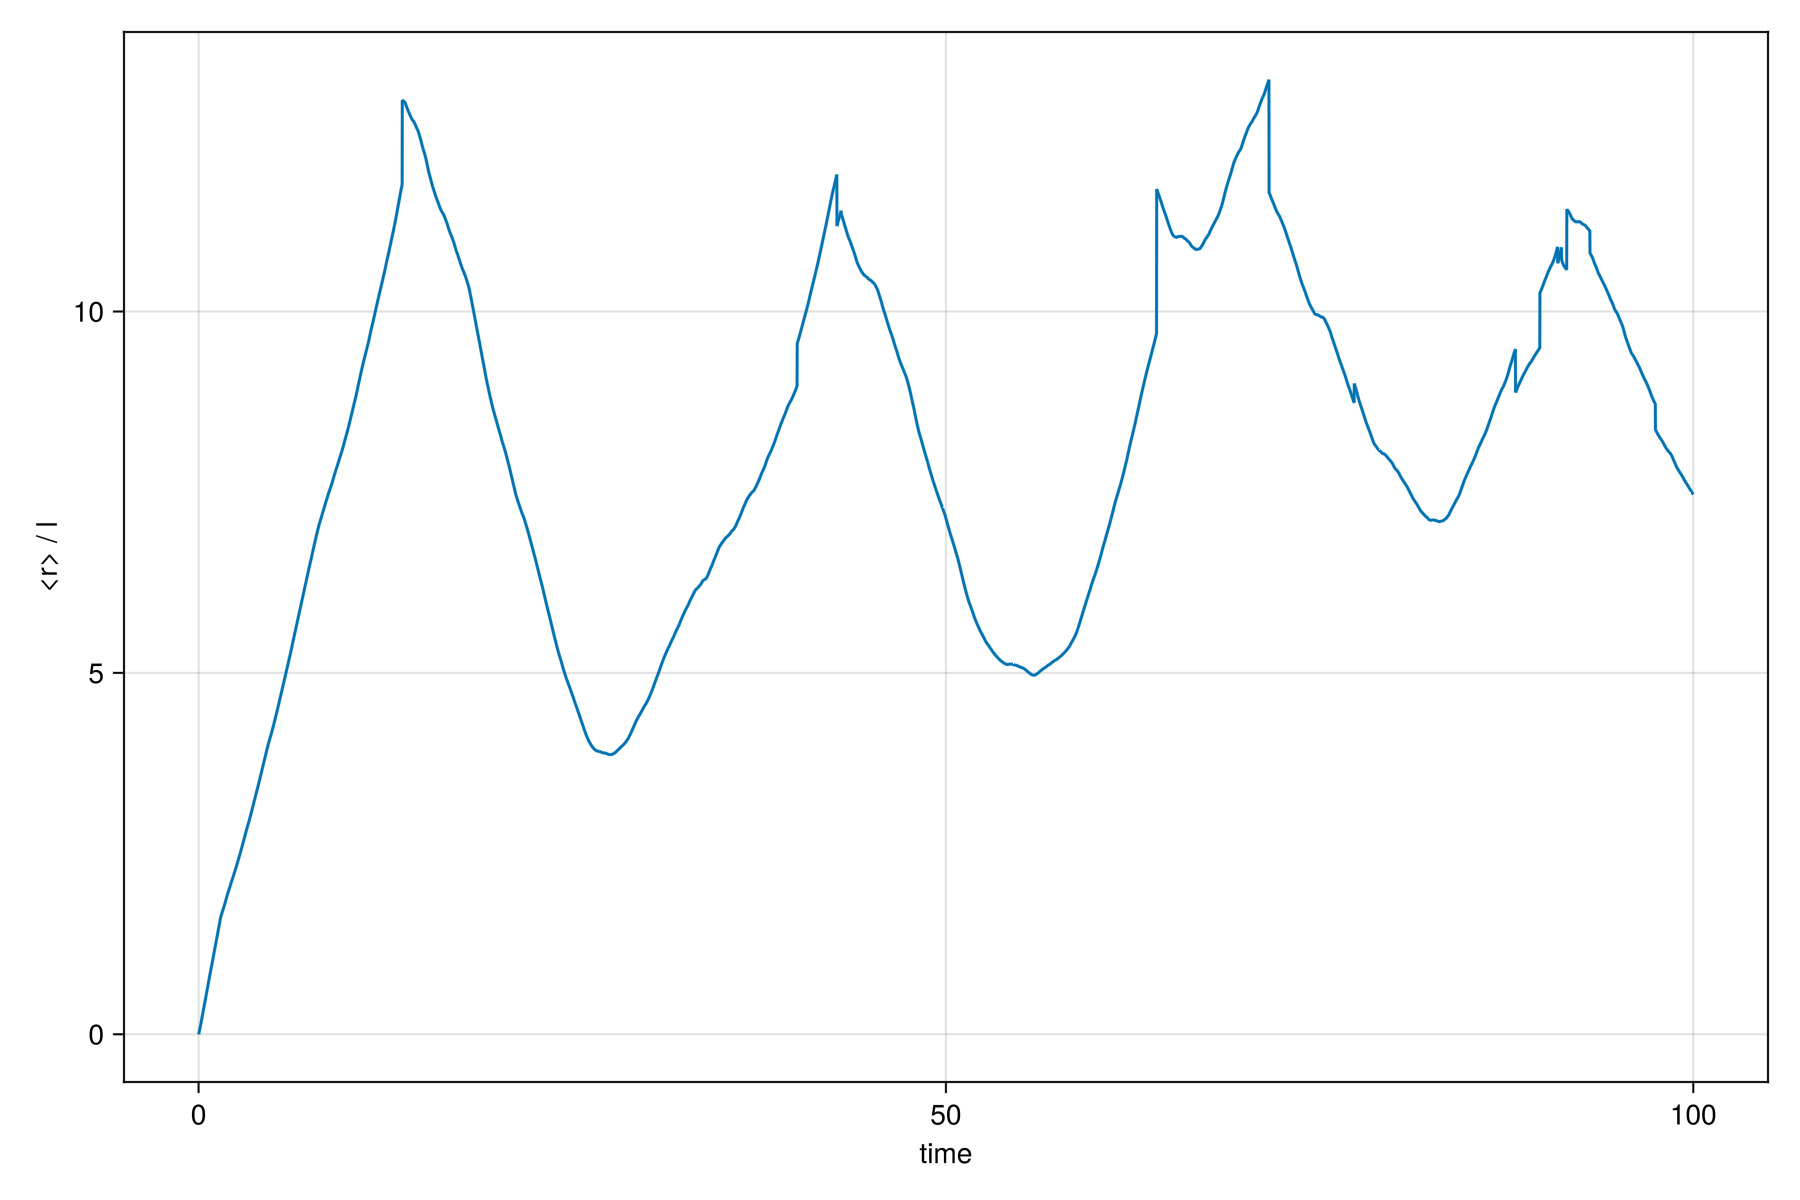

GLMakie.Screen(...)

In [23]:
fig = Figure(size=(900, 600))
ax1 = Axis(fig[1,1], xlabel="time", ylabel="<r> / l")

mean_dist = Float64[] 
time = (1:steps)  .*0.01
jldopen("ratios_1.jld2", "r") do file 

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        src = 1

        xs = g["x"][1]
        ys = g["y"][1]

        other_x = g["x"][2:com.N]
        other_y = g["y"][2:com.N]

        dists = sqrt.((other_x .- xs).^2 .+ (other_y .- ys).^2)

        push!(mean_dist, mean(dists))   
        
    end

    lines!(ax1, time, mean_dist ./ l)

end

display(fig)
